In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_280126/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
a01 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Calculated_amps/20cm_f11_a01_results.csv')
a01_p005 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Calculated_amps/20cm_f11_a01_p005_results.csv')
a02 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Calculated_amps/20cm_f11_a02_results.csv')
a02_p005 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Calculated_amps/20cm_f11_a02_p005_results.csv')
a03 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Calculated_amps/20cm_f11_a03_results.csv')
a03_p005 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Calculated_amps/20cm_f11_a03_p005_results.csv')

In [18]:
# Wavenumber
k = estimate_wavenumber(freq=1.1, depth=0.2)

# Theoretical damping coefficient
alpha_theo = spatial_damping_coefficient(k=k, D=0.2, H=0.15)

In [19]:
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])  # Base positions, meters from wave maker
plate_pos = np.array([6.34, 9.38])  # Positions of the plates, meters from wave maker

In [20]:
print('Theoretical damping coefficient at f=1.1 Hz:', f'{alpha_theo:.4f}')
print("--------------------------------")
print('Observed damping coefficients at f=1.1 Hz, A=0.1 V (no plates):')
print(f'{a01["Alpha_obs"][0]:.4f}', f'{a01["Alpha_obs"][1]:.4f}', f'{a01["Alpha_obs"][2]:.4f}')
print()
print('Observed damping coefficients at f=1.1 Hz, A=0.1 V (with 5 cm plates):')
print(f'{a01_p005["Alpha_obs"][0]:.4f}', f'{a01_p005["Alpha_obs"][1]:.4f}', f'{a01_p005["Alpha_obs"][2]:.4f}')
print()
print(f'Mean damping coefficient due to plates:')
print(f'{np.mean([a01_p005["Alpha_obs"][0], a01_p005["Alpha_obs"][1], a01_p005["Alpha_obs"][2]]) - np.mean([a01["Alpha_obs"][0], a01["Alpha_obs"][1], a01["Alpha_obs"][2]]):.4f}')
print("--------------------------------")
print('Observed damping coefficients at f=1.1 Hz, A=0.2 V (no plates):')
print(f'{a02["Alpha_obs"][0]:.4f}', f'{a02["Alpha_obs"][1]:.4f}', f'{a02["Alpha_obs"][2]:.4f}')
print()
print('Observed damping coefficients at f=1.1 Hz, A=0.2 V (with 5 cm plates):')
print(f'{a02_p005["Alpha_obs"][0]:.4f}', f'{a02_p005["Alpha_obs"][1]:.4f}', f'{a02_p005["Alpha_obs"][2]:.4f}')
print()
print(f'Mean damping coefficient due to plates:')
print(f'{np.mean([a02_p005["Alpha_obs"][0], a02_p005["Alpha_obs"][1], a02_p005["Alpha_obs"][2]]) - np.mean([a02["Alpha_obs"][0], a02["Alpha_obs"][1], a02["Alpha_obs"][2]]):.4f}')
print("--------------------------------")
print('Observed damping coefficients at f=1.1 Hz, A=0.3 V (no plates):')
print(f'{a03["Alpha_obs"][0]:.4f}', f'{a03["Alpha_obs"][1]:.4f}', f'{a03["Alpha_obs"][2]:.4f}')
print()
print('Observed damping coefficients at f=1.1 Hz, A=0.3 V (with 5 cm plates):')
print(f'{a03_p005["Alpha_obs"][0]:.4f}', f'{a03_p005["Alpha_obs"][1]:.4f}', f'{a03_p005["Alpha_obs"][2]:.4f}')
print()
print(f'Mean damping coefficient due to plates:')
print(f'{np.mean([a03_p005["Alpha_obs"][0], a03_p005["Alpha_obs"][1], a03_p005["Alpha_obs"][2]]) - np.mean([a03["Alpha_obs"][0], a03["Alpha_obs"][1], a03["Alpha_obs"][2]]):.4f}')

Theoretical damping coefficient at f=1.1 Hz: 0.0148
--------------------------------
Observed damping coefficients at f=1.1 Hz, A=0.1 V (no plates):
0.0110 0.0101 0.0106

Observed damping coefficients at f=1.1 Hz, A=0.1 V (with 5 cm plates):
0.0275 0.0280 0.0272

Mean damping coefficient due to plates:
0.0170
--------------------------------
Observed damping coefficients at f=1.1 Hz, A=0.2 V (no plates):
0.0104 0.0108 0.0106

Observed damping coefficients at f=1.1 Hz, A=0.2 V (with 5 cm plates):
0.0276 0.0273 0.0270

Mean damping coefficient due to plates:
0.0167
--------------------------------
Observed damping coefficients at f=1.1 Hz, A=0.3 V (no plates):
0.0101 0.0104 0.0108

Observed damping coefficients at f=1.1 Hz, A=0.3 V (with 5 cm plates):
0.0277 0.0276 0.0272

Mean damping coefficient due to plates:
0.0171


In [21]:
print('Amplitude change from first to last probe (no plates):')
for no, p005, label in zip([a01, a02, a03], [a01_p005, a02_p005, a03_p005], ['A=0.1 V', 'A=0.2 V', 'A=0.3 V']):
    P0_r1 = np.fromstring(no['Amp_obs'][0].strip('[]'), sep=' ')[0]
    P0_r2 = np.fromstring(no['Amp_obs'][1].strip('[]'), sep=' ')[0]
    P0_r3 = np.fromstring(no['Amp_obs'][2].strip('[]'), sep=' ')[0]

    P3_r1 = np.fromstring(no['Amp_obs'][0].strip('[]'), sep=' ')[-1]
    P3_r2 = np.fromstring(no['Amp_obs'][1].strip('[]'), sep=' ')[-1]
    P3_r3 = np.fromstring(no['Amp_obs'][2].strip('[]'), sep=' ')[-1]

    # Extract initial and final amplitudes for each run (with 5 cm plates)
    P0_p005_r1 = np.fromstring(p005['Amp_obs'][0].strip('[]'), sep=' ')[0]
    P0_p005_r2 = np.fromstring(p005['Amp_obs'][1].strip('[]'), sep=' ')[0]
    P0_p005_r3 = np.fromstring(p005['Amp_obs'][2].strip('[]'), sep=' ')[0]
    
    P3_p005_r1 = np.fromstring(p005['Amp_obs'][0].strip('[]'), sep=' ')[-1]   
    P3_p005_r2 = np.fromstring(p005['Amp_obs'][1].strip('[]'), sep=' ')[-1]
    P3_p005_r3 = np.fromstring(p005['Amp_obs'][2].strip('[]'), sep=' ')[-1]
    
    # Mean diff in amplitude between first and last probe
    P3_minus_P0_no = (np.mean(P3_r1 + P3_r2 + P3_r3) - np.mean(P0_r1 + P0_r2 + P0_r3))/np.mean(P0_r1 + P0_r2 + P0_r3)
    P3_minus_P0_p005 = (np.mean(P3_p005_r1 + P3_p005_r2 + P3_p005_r3) - np.mean(P0_p005_r1 + P0_p005_r2 + P0_p005_r3))/np.mean(P0_p005_r1 + P0_p005_r2 + P0_p005_r3)    
    print(f'{label}: No plates: {P3_minus_P0_no*100:.2f} %, With 5 cm plates: {P3_minus_P0_p005*100:.2f} %')

Amplitude change from first to last probe (no plates):
A=0.1 V: No plates: -4.51 %, With 5 cm plates: -10.96 %
A=0.2 V: No plates: -4.74 %, With 5 cm plates: -10.90 %
A=0.3 V: No plates: -4.57 %, With 5 cm plates: -10.91 %


In [34]:
print('Wave steepness (no plates):')
for no, label in zip([a01, a02, a03], ['A=0.1 V', 'A=0.2 V', 'A=0.3 V']):
    amp_r1 = np.fromstring(no['Amp_obs'][0].strip('[]'), sep=' ')
    amp_r2 = np.fromstring(no['Amp_obs'][1].strip('[]'), sep=' ')
    amp_r3 = np.fromstring(no['Amp_obs'][2].strip('[]'), sep=' ')
    A_mean = np.mean([amp_r1[0], amp_r2[0], amp_r3[0]])
    k = estimate_wavenumber(freq=1.1, depth=0.2)
    steepness = k*A_mean
    print(f'{label}: {steepness:.4f}')
print("--------------------------------")
print('Wave steepness (with 5 cm plates):')
for p005, label in zip([a01_p005, a02_p005, a03_p005], ['A=0.1 V', 'A=0.2 V', 'A=0.3 V']):
    amp_p005_r1 = np.fromstring(p005['Amp_obs'][0].strip('[]'), sep=' ')
    amp_p005_r2 = np.fromstring(p005['Amp_obs'][1].strip('[]'), sep=' ')
    amp_p005_r3 = np.fromstring(p005['Amp_obs'][2].strip('[]'), sep=' ')
    A_mean = np.mean([amp_p005_r1[0], amp_p005_r2[0], amp_p005_r3[0]])
    k = estimate_wavenumber(freq=1.1, depth=0.2)
    steepness = k*A_mean
    print(f'{label}: {steepness:.4f}')

Wave steepness (no plates):
A=0.1 V: 0.0271
A=0.2 V: 0.0541
A=0.3 V: 0.0817
--------------------------------
Wave steepness (with 5 cm plates):
A=0.1 V: 0.0273
A=0.2 V: 0.0546
A=0.3 V: 0.0824


In [22]:
amp_a01_r1_no = np.fromstring(a01['Amp_obs'][0].strip('[]'), sep=' ')
amp_a01_r1_p005 = np.fromstring(a01_p005['Amp_obs'][0].strip('[]'), sep=' ')
amp_a01_r2_no = np.fromstring(a01['Amp_obs'][1].strip('[]'), sep=' ')
amp_a01_r2_p005 = np.fromstring(a01_p005['Amp_obs'][1].strip('[]'), sep=' ')
amp_a01_r3_no = np.fromstring(a01['Amp_obs'][2].strip('[]'), sep=' ')
amp_a01_r3_p005 = np.fromstring(a01_p005['Amp_obs'][2].strip('[]'), sep=' ')

amp_a02_r1_no = np.fromstring(a02['Amp_obs'][0].strip('[]'), sep=' ')
amp_a02_r1_p005 = np.fromstring(a02_p005['Amp_obs'][0].strip('[]'), sep=' ')
amp_a02_r2_no = np.fromstring(a02['Amp_obs'][1].strip('[]'), sep=' ')
amp_a02_r2_p005 = np.fromstring(a02_p005['Amp_obs'][1].strip('[]'), sep=' ')
amp_a02_r3_no = np.fromstring(a02['Amp_obs'][2].strip('[]'), sep=' ')
amp_a02_r3_p005 = np.fromstring(a02_p005['Amp_obs'][2].strip('[]'), sep=' ')

amp_a03_r1_no = np.fromstring(a03['Amp_obs'][0].strip('[]'), sep=' ')
amp_a03_r1_p005 = np.fromstring(a03_p005['Amp_obs'][0].strip('[]'), sep=' ')
amp_a03_r2_no = np.fromstring(a03['Amp_obs'][1].strip('[]'), sep=' ')
amp_a03_r2_p005 = np.fromstring(a03_p005['Amp_obs'][1].strip('[]'), sep=' ')
amp_a03_r3_no = np.fromstring(a03['Amp_obs'][2].strip('[]'), sep=' ')
amp_a03_r3_p005 = np.fromstring(a03_p005['Amp_obs'][2].strip('[]'), sep=' ')    

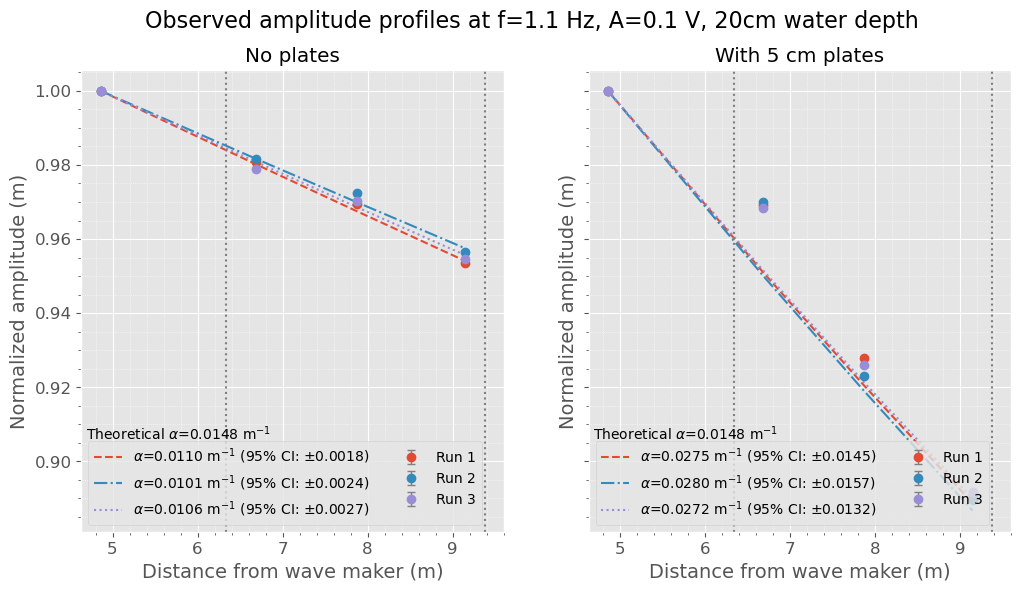

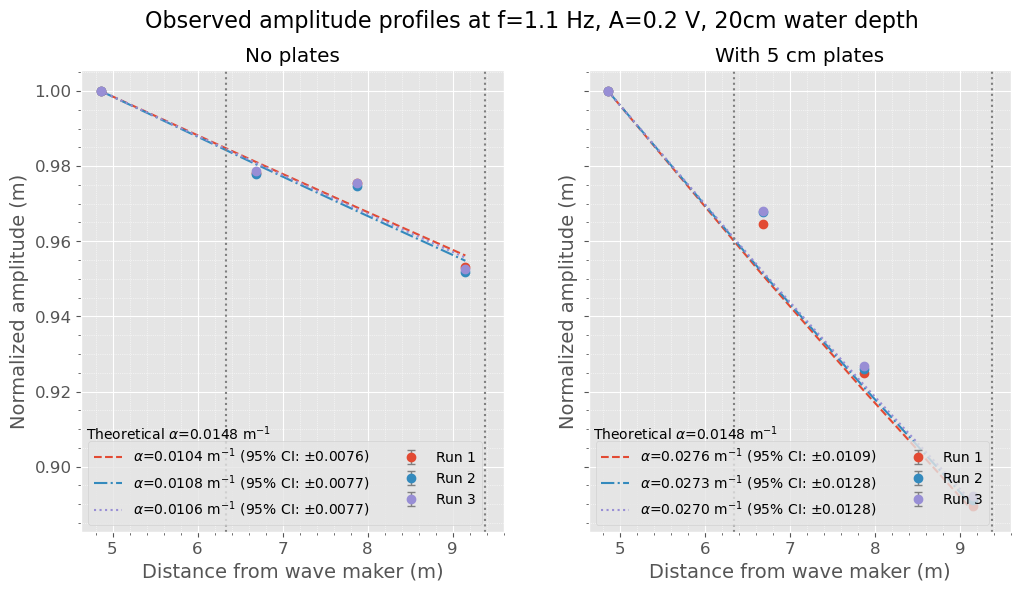

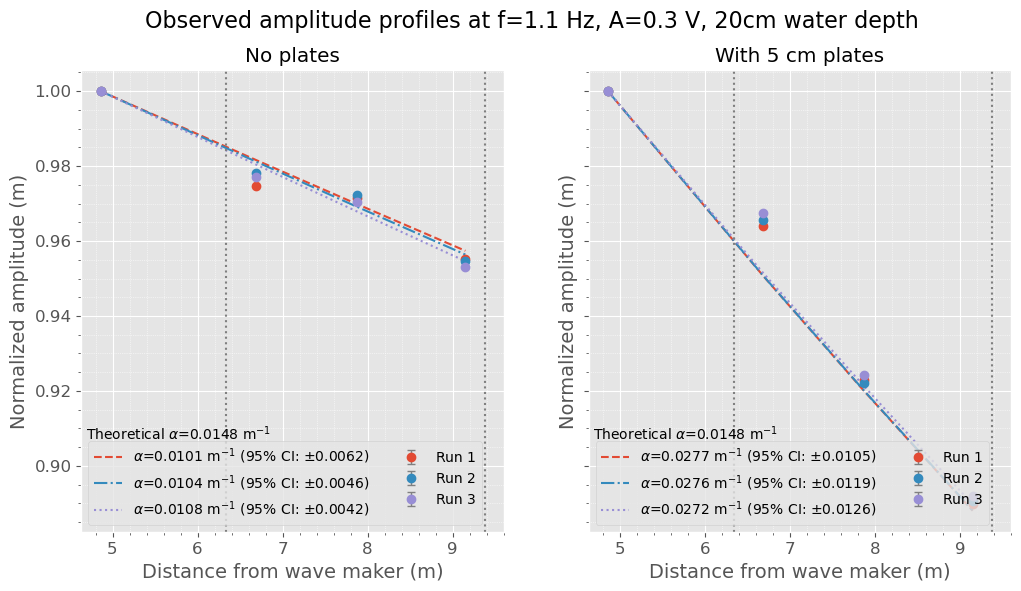

In [23]:
files = [(a01, a01_p005),
         (a02, a02_p005),
         (a03, a03_p005)]

volts = [0.1, 0.2, 0.3]

x_prof = x_probe_pos - x_probe_pos[0]  # positions relative to first probe

for (no, p005), volt in zip(files, volts):
    # Extract amplitudes and normalize by first probe amplitude
    amp_r1 = np.fromstring(no['Amp_obs'][0].strip('[]'), sep=' ')
    amp_r1 = amp_r1/amp_r1[0]
    amp_r2 = np.fromstring(no['Amp_obs'][1].strip('[]'), sep=' ')
    amp_r2 = amp_r2/amp_r2[0]
    amp_r3 = np.fromstring(no['Amp_obs'][2].strip('[]'), sep=' ')
    amp_r3 = amp_r3/amp_r3[0]

    amp_p005_r1 = np.fromstring(p005['Amp_obs'][0].strip('[]'), sep=' ')
    amp_p005_r1 = amp_p005_r1/amp_p005_r1[0]
    amp_p005_r2 = np.fromstring(p005['Amp_obs'][1].strip('[]'), sep=' ')
    amp_p005_r2 = amp_p005_r2/amp_p005_r2[0]
    amp_p005_r3 = np.fromstring(p005['Amp_obs'][2].strip('[]'), sep=' ')
    amp_p005_r3 = amp_p005_r3/amp_p005_r3[0]

    # Extract amplitude errors
    err_r1 = np.fromstring(no['Amp_errors'][0].strip('[]'), sep=' ')
    err_r2 = np.fromstring(no['Amp_errors'][1].strip('[]'), sep=' ')
    err_r3 = np.fromstring(no['Amp_errors'][2].strip('[]'), sep=' ')

    err_p005_r1 = np.fromstring(p005['Amp_errors'][0].strip('[]'), sep=' ')
    err_p005_r2 = np.fromstring(p005['Amp_errors'][1].strip('[]'), sep=' ')
    err_p005_r3 = np.fromstring(p005['Amp_errors'][2].strip('[]'), sep=' ')

    # Mean diff in amplitude between first and last probe
    #P3_minus_P0_no = (np.mean(amp_r1[-1] + amp_r2[-1] + amp_r3[-1]) - np.mean(amp_r1[0] + amp_r2[0] + amp_r3[0]))/np.mean(amp_r1[0] + amp_r2[0] + amp_r3[0])
    #P3_minus_P0_p005 = (np.mean(amp_p005_r1[-1] + amp_p005_r2[-1] + amp_p005_r3[-1]) - np.mean(amp_p005_r1[0] + amp_p005_r2[0] + amp_p005_r3[0]))/np.mean(amp_p005_r1[0] + amp_p005_r2[0] + amp_p005_r3[0])

    fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12,6))

    ax[0].errorbar(x_probe_pos,
                   amp_r1,
                   yerr=err_r1,
                   fmt='o', color='C0', ecolor='0.5', elinewidth=1, capsize=3, label='Run 1')
    ax[0].errorbar(x_probe_pos,
                   amp_r2,
                   yerr=err_r2,
                   fmt='o', color='C1', ecolor='0.5', elinewidth=1, capsize=3, label='Run 2')
    ax[0].errorbar(x_probe_pos,
                   amp_r3,
                   yerr=err_r3,
                   fmt='o', color='C2', ecolor='0.5', elinewidth=1, capsize=3, label='Run 3')

    ax[1].errorbar(x_probe_pos,
                   amp_p005_r1,
                   yerr=err_p005_r1,
                   fmt='o', color='C0', ecolor='0.5', elinewidth=1, capsize=3, label='Run 1')
    ax[1].errorbar(x_probe_pos,
                   amp_p005_r2,
                   yerr=err_p005_r2,
                   fmt='o', color='C1', ecolor='0.5', elinewidth=1, capsize=3, label='Run 2')
    ax[1].errorbar(x_probe_pos,
                   amp_p005_r3,
                   yerr=err_p005_r3,
                   fmt='o', color='C2', ecolor='0.5', elinewidth=1, capsize=3, label='Run 3')

    #ax[0].annotate(r'$P_3 - P_0$' + f' = {P3_minus_P0_no:.4f} m', xy=(0.4, 0.9), xycoords='axes fraction', fontsize=12, color='black')
    #ax[1].annotate(r'$P_3 - P_0$' + f' = {P3_minus_P0_p005:.4f} m', xy=(0.4, 0.9), xycoords='axes fraction', fontsize=12, color='black')

    ax[0].annotate(rf'Theoretical $\alpha$={alpha_theo:.4f} m$^{{-1}}$', xy=(0.01, 0.2), xycoords='axes fraction', fontsize=10, color='black')
    ax[1].annotate(rf'Theoretical $\alpha$={alpha_theo:.4f} m$^{{-1}}$', xy=(0.01, 0.2), xycoords='axes fraction', fontsize=10, color='black')


    # Plot fitted exponential decay curves and show alpha with CI bounds in legend
    ax[0].plot(
    x_probe_pos, amp_r1[0]*np.exp(-no['Alpha_obs'][0]*x_prof),
    color='C0', linestyle='--',
    label=rf'$\alpha$={no["Alpha_obs"][0]:.4f} m$^{{-1}}$ (95% CI: $\pm {no["T_val"][0]*no["SE_Alpha_obs"][0]:.4f}$)'
)
    ax[0].plot(
    x_probe_pos, amp_r2[0]*np.exp(-no['Alpha_obs'][1]*x_prof),
    color='C1', linestyle='-.',
    label=rf'$\alpha$={no["Alpha_obs"][1]:.4f} m$^{{-1}}$ (95% CI: $\pm {no["T_val"][1]*no["SE_Alpha_obs"][1]:.4f}$)'
)
    ax[0].plot(
    x_probe_pos, amp_r3[0]*np.exp(-no['Alpha_obs'][2]*x_prof),
    color='C2', linestyle=':',
    label=rf'$\alpha$={no["Alpha_obs"][2]:.4f} m$^{{-1}}$ (95% CI: $\pm {no["T_val"][2]*no["SE_Alpha_obs"][2]:.4f}$)'
)

    ax[1].plot(
    x_probe_pos, amp_p005_r1[0]*np.exp(-p005['Alpha_obs'][0]*x_prof),
    color='C0', linestyle='--',
    label=rf'$\alpha$={p005["Alpha_obs"][0]:.4f} m$^{{-1}}$ (95% CI: $\pm {p005["T_val"][0]*p005["SE_Alpha_obs"][0]:.4f}$)'
)
    ax[1].plot(
    x_probe_pos, amp_p005_r2[0]*np.exp(-p005['Alpha_obs'][1]*x_prof),
    color='C1', linestyle='-.',
    label=rf'$\alpha$={p005["Alpha_obs"][1]:.4f} m$^{{-1}}$ (95% CI: $\pm {p005["T_val"][1]*p005["SE_Alpha_obs"][1]:.4f}$)'
)
    ax[1].plot(
    x_probe_pos, amp_p005_r3[0]*np.exp(-p005['Alpha_obs'][2]*x_prof),
    color='C2', linestyle=':',
    label=rf'$\alpha$={p005["Alpha_obs"][2]:.4f} m$^{{-1}}$ (95% CI: $\pm {p005["T_val"][2]*p005["SE_Alpha_obs"][2]:.4f}$)'
)

    for axs in ax:
        axs.set_xlabel('Distance from wave maker (m)', fontsize=14)
        axs.set_ylabel('Normalized amplitude (m)', fontsize=14)
        axs.tick_params(axis='both', which='major', labelsize=12)
        axs.legend(loc='lower left', ncol=2, fontsize=10)
        axs.grid(which='minor', linestyle=':', linewidth='0.5', color='white')
        axs.minorticks_on()
        axs.axvline(x=plate_pos[0], color='0.5', linestyle=':')
        axs.axvline(x=plate_pos[1], color='0.5', linestyle=':')

    ax[0].set_title('No plates')
    ax[1].set_title('With 5 cm plates')

    fig.suptitle(f'Observed amplitude profiles at f=1.1 Hz, A={volt} V, 20cm water depth', fontsize=16)